# Week 4 Assignment

- 2021041017 Kim Gyu Hyeon (김규현)

In [32]:
import torch
import torchaudio
import torchaudio.functional as F
import torchaudio.transforms as T
from IPython.display import Audio, display

print(torch.__version__)
print(torchaudio.__version__)

import matplotlib.pyplot as plt
import librosa

2.8.0+cu126
2.8.0+cu126


- file upload

In [79]:
from google.colab import files
uploaded = files.upload()

SAMPLE_AUDIO = list(uploaded.keys())[0]

display(Audio(SAMPLE_AUDIO))

waveform, sample_rate = torchaudio.load(SAMPLE_AUDIO)
if waveform.size(0) > 1:
  waveform = waveform.mean(dim=0, keepdim=True)

print("waveform:", waveform.shape, "sample_rate:", sample_rate)

Saving sample_audio1.mp3 to sample_audio1.mp3


waveform: torch.Size([1, 78912]) sample_rate: 24000


- Feature extraction

In [80]:
def plot_waveform(waveform, sr, title="Waveform", ax=None):
    waveform = waveform.numpy()

    num_channels, num_frames = waveform.shape
    time_axis = torch.arange(0, num_frames) / sr

    if ax is None:
        _, ax = plt.subplots(num_channels, 1)
    ax.plot(time_axis, waveform[0], linewidth=1)
    ax.grid(True)
    ax.set_xlim([0, time_axis[-1]])
    ax.set_title(title)

def plot_spectrogram(specgram, title=None, ylabel="freq_bin", ax=None):
    if ax is None:
        _, ax = plt.subplots(1, 1)
    if title is not None:
        ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.imshow(librosa.power_to_db(specgram), origin="lower", aspect="auto", interpolation="nearest")

def plot_fbank(fbank, title=None):
    fig, axs = plt.subplots(1, 1)
    axs.set_title(title or "Filter bank")
    axs.imshow(fbank, aspect="auto")
    axs.set_ylabel("frequency bin")
    axs.set_xlabel("mel bin")

- Spectrogram

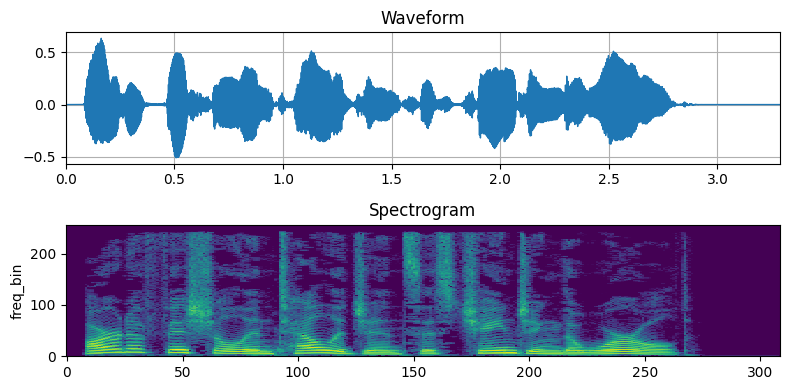

In [81]:
# Spectrogram
spectrogram = T.Spectrogram(n_fft=512)
spec = spectrogram(waveform)
fig, axs = plt.subplots(2, 1, figsize=(8,4))
plot_waveform(waveform, sample_rate, title="Waveform", ax=axs[0])
plot_spectrogram(spec[0].numpy(), title="Spectrogram", ax=axs[1])
fig.tight_layout()

- MelSpectrogram

<Figure size 800x300 with 0 Axes>

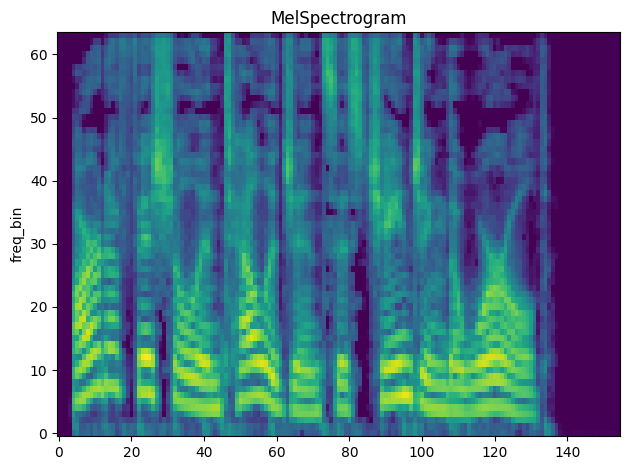

In [82]:
# MelSpectrogram
melspec_tf = T.MelSpectrogram(sample_rate=sample_rate, n_fft=1024,
                              hop_length=512, n_mels=64)
melspec = melspec_tf(waveform)
plt.figure(figsize=(8,3))
plot_spectrogram(melspec[0].numpy(), title="MelSpectrogram")
plt.tight_layout()


- MFCC

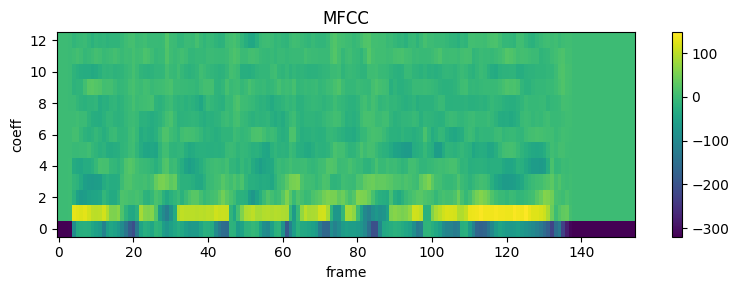

In [83]:
# MFCC
mfcc_tf = T.MFCC(sample_rate=sample_rate, n_mfcc=13,
                 melkwargs={"n_fft":1024, "hop_length":512, "n_mels":64})
mfcc = mfcc_tf(waveform)
plt.figure(figsize=(8,3))
plt.imshow(mfcc[0].numpy(), origin="lower", aspect="auto", interpolation="nearest")
plt.title("MFCC")
plt.ylabel("coeff")
plt.xlabel("frame")
plt.colorbar()
plt.tight_layout()

- Wav2Vec2 ASR

In [91]:
# Wav2Vec2 ASR
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bundle = torchaudio.pipelines.WAV2VEC2_ASR_BASE_960H
model = bundle.get_model().to(device).eval()

if sample_rate != bundle.sample_rate:
    waveform = torchaudio.functional.resample(waveform, sample_rate, bundle.sample_rate)
    sample_rate = bundle.sample_rate

with torch.inference_mode():
    emission, _ = model(waveform.to(device))

class GreedyCTCDecoder(torch.nn.Module):
    def __init__(self, labels, blank=0):
        super().__init__()
        self.labels = labels
        self.blank = blank
    def forward(self, emission: torch.Tensor) -> str:
        indices = torch.argmax(emission, dim=-1)
        indices = torch.unique_consecutive(indices, dim=-1)
        indices = [i for i in indices if i != self.blank]
        return "".join([self.labels[i] for i in indices]).replace("|"," ").strip()

decoder = GreedyCTCDecoder(labels=bundle.get_labels())
transcript = decoder(emission[0].cpu())

print("Transcript:", transcript)
print("\nPlay audio:")
display(Audio(SAMPLE_AUDIO))

Transcript: ARTIFICIAL INTELLIGENCE IS CHANGING THE WORLD

Play audio:
